# Notebook 1 — Setup and data loading

This notebook prepares the environment for the city-level heat-risk analysis (illustrated here for **Rome**, but written to be city-agnostic).

Specifically, it:

- **Initialises the environment**
  - Loads libraries (`numpy`, `pandas`, `xarray`, `rasterio`, `geopandas`, `climada`), prints versions, and sets a reproducible Python environment.
  - Uses the project bootstrap (`cityheat.nbsetup.bootstrap`) to read the city config (`configs/<slug>.yml`) and define consistent paths for **BASE**, **OUT**, and **INT** folders.
  - Sets the city slug (default: `rome`) but keeps all paths and logic generic so other cities can be plugged in by changing a single flag.

- **Syncs input data from Google Drive**
  - Reads a **city-specific Drive manifest** and uses `gdown` to ensure all required input files (FUA boundaries, LCZ maps, UrbClim heat metrics, WorldPop grids, AC penetration and kWh data, vulnerability layers, cooling-efficiency coefficients, etc.) are present and up-to-date in the local `data/<city>` folder.
  - Logs any sync failures and writes lightweight “.synced” sidecar files to avoid unnecessary re-downloads.

- **Downloads UrbClim T2M data from the API**
  - Connects to the UrbClim API for the city and downloads **daily mean 2 m temperature** NetCDF files for 2008–2017 into a local folder.
  - These files are used later to build a baseline climatology.

- **Loads and inspects key spatial layers**
  - **FUA boundary:** reads the functional urban area polygon, checks its CRS, and uses it as the reference spatial footprint for all subsequent masking and aggregation.
  - **LCZ rasters:** loads the `lcz_filter_v3.tif` map, crops it to the FUA, and saves a masked raster (`lcz_masked_fua.tif`). Computes the distribution of LCZ classes (all and built-only) to characterise the city’s urban form.
  - **GVI point data:** reads the city-level Green View Index CSV (x/y coordinates, LCZ class, GVI), checks required columns, and prepares it for later linkage/merge with LCZ and cooling coefficients.
  - **UrbClim T2M NetCDF:** inspects file structure (dimensions, variables, time coverage) to confirm compatibility.

- **Builds a baseline T2M climatology**
  - Opens all `T2M_year_daily_mean_*.nc` files and aggregates daily mean temperature to **monthly means** over 2008–2017.
  - Derives a **monthly climatology** (12 maps) and computes the city-mean and FUA-mean seasonal cycle in °C, which is plotted and tabulated for reference.
  - Creates an FUA mask on the UrbClim grid to ensure consistent area averages.

- **Explores cooling-efficiency coefficients**
  - Reads the six `CoolingEff` CSVs (air temperature and WBGT, min/mean/max) that provide **LCZ-specific coefficients** linking a 1-unit increase in GVI to a change in °C.
  - Confirms their structure (city name, month, LCZ, `coef`, `coef_abs`) and stores them for later use when converting ΔGVI into cooling effects.

In summary, Notebook 1 sets up the Python environment, synchronises and validates all core input datasets (geometry, climate, population, vulnerability, cooling response), and computes a first set of **baseline diagnostics** or **descriptive statistics** (LCZ mix, T2M climatology) to prepare all subsequent notebooks.

In [1]:
import sys
import importlib
import importlib.metadata as im

import numpy as np, pandas as pd
import climada as cl
import xarray as xr, rasterio, geopandas as gpd

print("Python:", sys.version.split()[0])
print("Kernel exe:", sys.executable)
print("climada module path:", getattr(cl, "__file__", "<none>"))

try:
    print("CLIMADA:", cl.__version__)
except AttributeError:
    try:
        print("CLIMADA:", im.version("climada"))
    except im.PackageNotFoundError:
        print("CLIMADA: <not found in package metadata>")

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("xarray:", xr.__version__)
print("rasterio:", rasterio.__version__)
print("geopandas:", gpd.__version__)

Python: 3.10.19
Kernel exe: /opt/anaconda3/envs/urbanheat/bin/python
climada module path: /opt/anaconda3/envs/urbanheat/lib/python3.10/site-packages/climada/__init__.py
CLIMADA: 6.1.0
NumPy: 1.26.4
Pandas: 2.1.4
xarray: 2025.6.1
rasterio: 1.4.3
geopandas: 1.1.1


In [2]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [3]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()
# rome is a default, it has no importance

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [4]:
# generic Drive sync (city-aware) 
from pathlib import Path
import json, gdown
from datetime import datetime

CFG_PATH = C["CFG"]          # Path to configs/<slug>.yml
cfg      = C["cfg"]          # dict loaded from YAML
base_dir = Path(C["BASE"]).resolve()

# drive_manifest is relative to repo root in YAML
manifest_path = (ROOT / cfg["drive_manifest"]).resolve()
M = json.loads(Path(manifest_path).read_text())

def _append_log(path: Path, line: str):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as fh:
        fh.write(line + "\n")

def _sidecar(p: Path) -> Path:
    return p.with_suffix(p.suffix + ".synced")

def _need(dest: Path, force: bool) -> bool:
    sc = _sidecar(dest)
    return force or (not dest.exists()) or (not sc.exists())

def _note_ok(dest: Path, id_: str):
    sc = _sidecar(dest)
    sc.write_text(json.dumps({"id": id_, "size": dest.stat().st_size if dest.exists() else None,
                              "when": datetime.now().isoformat()}))

def sync_from_gdrive(M, base_dir: Path, use_cookies=True, force=False, only=None):
    base_dir.mkdir(parents=True, exist_ok=True)
    failures = []
    def _selected(rel): return True if not only else any(rel.startswith(pfx) for pfx in only)

    for e in M["entries"]:
        if not _selected(e["dest"]): 
            continue
        e_type, e_id = e.get("type", "file"), e["id"]
        dest = (base_dir / e["dest"]).resolve()
        dest.parent.mkdir(parents=True, exist_ok=True)
        try:
            if e_type == "folder":
                marker = dest / ".synced.ok"
                needs = force or (not dest.exists()) or (not any(dest.iterdir())) or (not marker.exists())
                if needs:
                    print(f"↻ Folder: {e_id} → {dest}")
                    gdown.download_folder(id=e_id, output=str(dest), quiet=False,
                                          use_cookies=use_cookies, remaining_ok=True)
                    marker.write_text(json.dumps({"id": e_id, "when": datetime.now().isoformat()}))
                else:
                    print(f"✓ Folder up-to-date: {dest}")
            else:
                if _need(dest, force):
                    print(f"↻ File:   {e_id} → {e['dest']}")
                    url = f"https://drive.google.com/uc?id={e_id}"
                    out = gdown.download(url=url, output=str(dest), quiet=False, use_cookies=use_cookies)
                    if out is None or not dest.exists():
                        raise RuntimeError("gdown returned None or file missing.")
                    _note_ok(dest, e_id)
                else:
                    print(f"✓ File up-to-date: {e['dest']}")
        except Exception as ex:
            errlog = (dest if e_type == "file" else (dest/".folder")).with_suffix(".sync_errors.log")
            _append_log(errlog, f"[{datetime.now().isoformat()}] {e_type.upper()} {e_id} → {dest} FAILED: {ex}")
            print(f"✗ FAIL {e_type} {dest} — {ex}")
            failures.append({"type": e_type, "id": e_id, "dest": str(dest), "error": str(ex)})

    if failures:
        print("\n=== SUMMARY: failures that need attention ===")
        for f in failures:
            print(f"- {f['type']} → {f['dest']} :: {f['error']}\n"
                  f"  Action: check Drive item and update ID in {manifest_path}")
    else:
        print("\nAll entries synced successfully.")

print(f"→ Syncing Drive for {cfg['city_name']} (slug={SLUG}) from {manifest_path}")
sync_from_gdrive(M, base_dir, use_cookies=True, force=False)

→ Syncing Drive for Genova (slug=genova) from /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data_manifests/genova_gdrive.json
✓ File up-to-date: CAPZONE/CAPZONE.shp
✓ File up-to-date: CAPZONE/CAPZONE.shx
✓ File up-to-date: CAPZONE/CAPZONE.dbf
✓ File up-to-date: CAPZONE/CAPZONE.prj
✓ File up-to-date: CAPZONE/CAPZONE.cpg
✓ File up-to-date: CAPZONE/CAPZONE.sbn
✓ File up-to-date: CAPZONE/CAPZONE.sbx
✓ File up-to-date: CAPZONE/CAPZONE.shp.xml
✓ File up-to-date: UrbClim/UrbClimWBGTmax/UrbClimWBGTmax.zip
✓ File up-to-date: fua/genova_fua_ghs_4326.dbf
✓ File up-to-date: fua/genova_fua_ghs_4326.geojson
✓ File up-to-date: fua/genova_fua_ghs_4326.prj
✓ File up-to-date: fua/genova_fua_ghs_4326.shp
✓ File up-to-date: fua/genova_fua_ghs_4326.shx
✓ File up-to-date: gviGenova/gvi_Genova.csv
✓ File up-to-date: LCZ/00_global_map_of_LCZs.png
✓ File up-to-date: LCZ/lcz_filter_v3.tif
✓ File up-to-date: LCZ/lcz_v3.tif
✓ File up-to-date: vulnerability/GHS_AGE_1975052020_GLOBE_R2025A_54009_100_

In [5]:
# UrbClim T2M from API (Vito API)
import requests, re
from pathlib import Path

clim_cfg = cfg.get("climate", {})
api_cfg  = clim_cfg.get("urbclim_api", {})

def ensure_urbclim_t2m_from_api(api_cfg, base_dir: Path):
    if not api_cfg.get("enabled", False):
        print("UrbClim API download disabled in config.")
        return

    url       = api_cfg.get("t2m_url")
    local_rel = api_cfg.get("local_dir", "UrbClim/UrbClimT2Mmean")
    years     = api_cfg.get("years", list(range(2008, 2018)))

    if not url:
        print("No 't2m_url' configured in climate.urbclim_api → skipping.")
        return

    local_dir = (base_dir / local_rel).resolve()
    local_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n→ Ensuring UrbClim T2M (daily mean) from API:")
    print(f"   URL:      {url}")
    print(f"   Local dir:{local_dir}")
    print(f"   Years:    {years}")

    try:
        r = requests.get(url)
        r.raise_for_status()
    except Exception as ex:
        print(f"✗ Failed to fetch directory listing from API: {ex}")
        return

    # find all .nc links in the HTML
    links = re.findall(r'href="([^"]+\.nc)"', r.text)
    available = set(links)

    for year in years:
        fname = f"T2M_year_daily_mean_{year}.nc"
        dest  = local_dir / fname

        if dest.exists():
            print(f"✓ {fname} already present locally.")
            continue

        if fname not in available:
            print(f"⚠ {fname} not found in API listing at {url}")
            continue

        file_url = url.rstrip("/") + "/" + fname
        print(f"↓ Downloading {file_url} → {dest}")
        try:
            with requests.get(file_url, stream=True) as resp:
                resp.raise_for_status()
                with open(dest, "wb") as f:
                    for chunk in resp.iter_content(chunk_size=2**20):
                        if chunk:
                            f.write(chunk)
        except Exception as ex:
            print(f"✗ Failed to download {fname}: {ex}")

# call it
ensure_urbclim_t2m_from_api(api_cfg, base_dir)


→ Ensuring UrbClim T2M (daily mean) from API:
   URL:      https://provide.marvin.vito.be/ftp/compressed_daily/Genoa/
   Local dir:/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/UrbClim/UrbClimT2Mmean
   Years:    [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
✓ T2M_year_daily_mean_2008.nc already present locally.
✓ T2M_year_daily_mean_2009.nc already present locally.
✓ T2M_year_daily_mean_2010.nc already present locally.
✓ T2M_year_daily_mean_2011.nc already present locally.
✓ T2M_year_daily_mean_2012.nc already present locally.
✓ T2M_year_daily_mean_2013.nc already present locally.
✓ T2M_year_daily_mean_2014.nc already present locally.
✓ T2M_year_daily_mean_2015.nc already present locally.
✓ T2M_year_daily_mean_2016.nc already present locally.
✓ T2M_year_daily_mean_2017.nc already present locally.


## Loading packages and main data 

In [6]:
import os, sys, glob, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# geospatial packages 
import rasterio
from rasterio.plot import show
from rasterio.enums import Resampling
import geopandas as gpd
from rasterio.mask import mask
import rasterio as rio

# for the netCDF 
import xarray as xr

plt.rcParams["figure.dpi"] = 130

p_LCZ     = P("LCZ")
p_UrbClim = P("UrbClim/UrbClimT2Mmean")   
gvi_csv = P(cfg["files"]["gvi_csv"])
p_GVI   = gvi_csv.parent 
p_CoolEff = P("CoolingEff")              
p_FUA     = P("fua")
p_CAP     = P("CAPZONE")

In [7]:
# CoolingEff
coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
print("CoolingEff CSVs:", [f.name for f in coolingeff_csvs] or "none (folder is empty)")

# UrbClim
nc_files = sorted(p_UrbClim.glob("T2M_year_daily_mean*.nc"))
print(f"UrbClim .nc files found: {len(nc_files)}")
for f in nc_files[:6]:
    print(" •", f.name)

CoolingEff CSVs: ['outer_2_max.csv', 'outer_2_mean.csv', 'outer_2_min.csv', 'outer_2_wbgt_max.csv', 'outer_2_wbgt_mean.csv', 'outer_2_wbgt_min.csv']
UrbClim .nc files found: 10
 • T2M_year_daily_mean_2008.nc
 • T2M_year_daily_mean_2009.nc
 • T2M_year_daily_mean_2010.nc
 • T2M_year_daily_mean_2011.nc
 • T2M_year_daily_mean_2012.nc
 • T2M_year_daily_mean_2013.nc


**FUA Boundaries**

In [8]:
from pathlib import Path

p_FUA = P("fua")

# I took the FUA from GHS databases (did it on a R notebook, that I can put in the repository) 

# making it city agnostic
candidates = list(p_FUA.glob(f"*{SLUG}*_ghs_4326.*"))
prio = {".geojson": 0, ".gpkg": 1, ".shp": 2}
candidates = sorted(candidates, key=lambda p: prio.get(p.suffix.lower(), 99))
assert candidates, f"No FUA file found for {SLUG} in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
print("FUA CRS:", fua.crs)
display(fua.head())

FUA CRS: EPSG:4326


,name,iso,efua_id,geometry
0,Genoa,ITA,1309.0,"MULTIPOLYGON (((8.9637 44.62028, 8.93904 44.62..."


**Inspecting datasets**

**LCZ rasters**

In [9]:
list(p_LCZ.glob("*")) # listing files, the important one is lcz_filter_v3

[PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/00_global_map_of_LCZs.png.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/00_global_map_of_LCZs.png'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif.synced'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif'),
 PosixPath('/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif.synced')]

In [10]:
lcz_path = P("LCZ/lcz_filter_v3.tif")

with rasterio.open(lcz_path) as src:
    # align FUA CRS to the raster’s CRS (according to the Readme the LCZ is EPSG:4326, but just to be sure)
    fua_aligned = fua.to_crs(src.crs)
    geoms = [g.__geo_interface__ for g in fua_aligned.geometry if g is not None]

    # masking + cropping to the minimal bounding window around the FUA
    out, out_transform = mask(src, geoms, crop=True, filled=True)
    lcz_fua = out[0]                       # single-band raster 
    lcz_meta = src.meta.copy()
    lcz_meta.update({"transform": out_transform,
                     "height": lcz_fua.shape[0],
                     "width":  lcz_fua.shape[1]})
    nodata_val = src.nodata

print("LCZ masked shape:", lcz_fua.shape, "| nodata:", nodata_val)

LCZ masked shape: (318, 722) | nodata: 0.0


Map of masked LCZ

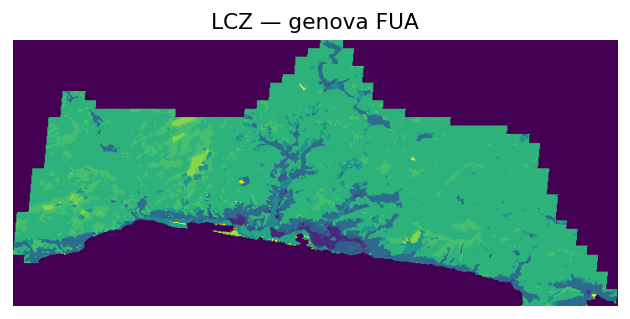

In [11]:
plt.figure(figsize=(6,5))
plt.imshow(lcz_fua, origin="upper")
plt.title(f"LCZ — {CITY} FUA")
plt.axis("off")
plt.show()

Counting pixels by LCZ class and computing shares

In [12]:
# treating nodata/zeros as invalid. LCZ classes are 1..17 (1-10:built-up, 11-17:natural)
valid = np.isfinite(lcz_fua) & (lcz_fua > 0)
vals = lcz_fua[valid].astype(int)

uniq, cnt = np.unique(vals, return_counts=True)

lcz_names = { # mapping of lcz names to numbers based on the article 
    1:"Compact highrise",  2:"Compact midrise",  3:"Compact lowrise",
    4:"Open highrise",     5:"Open midrise",     6:"Open lowrise",
    7:"Lightweight low-rise", 8:"Large lowrise", 9:"Sparsely built",
    10:"Heavy industry",
    11:"Dense trees", 12:"Scattered trees", 13:"Bush, scrub",
    14:"Low plants",  15:"Bare rock/paved", 16:"Bare soil/sand", 17:"Water"
}

df_lcz = (pd.DataFrame({"LCZ": uniq, "pixels": cnt})
            .assign(name=lambda d: d["LCZ"].map(lcz_names),
                    share_pct=lambda d: 100 * d["pixels"] / d["pixels"].sum())
            .sort_values("LCZ")
            .reset_index(drop=True))

display(df_lcz)

,LCZ,pixels,name,share_pct
0,1,6,Compact highrise,0.005287
1,2,1058,Compact midrise,0.932233
2,3,232,Compact lowrise,0.204421
3,4,245,Open highrise,0.215876
4,5,1568,Open midrise,1.381607
5,6,10990,Open lowrise,9.683587
6,8,1533,Large lowrise,1.350768
7,9,4032,Sparsely built,3.552705
8,10,937,Heavy industry,0.825616
9,11,79454,Dense trees,70.009076


Built categories only shares (no natural)

In [13]:
# Calculating the shares over just the built LCZ classes (from 1 to 10)
built_mask = df_lcz["LCZ"].between(1, 10)
built_total = df_lcz.loc[built_mask, "pixels"].sum()

df_lcz_built = (df_lcz.loc[built_mask, ["LCZ","name","pixels"]]
                    .assign(share_pct_within_built=lambda d: 100 * d["pixels"] / built_total)
                    .reset_index(drop=True))

print("Shares over BUILT classes only (1–10):")
display(df_lcz_built)

Shares over BUILT classes only (1–10):


,LCZ,name,pixels,share_pct_within_built
0,1,Compact highrise,6,0.029125
1,2,Compact midrise,1058,5.135673
2,3,Compact lowrise,232,1.126159
3,4,Open highrise,245,1.189263
4,5,Open midrise,1568,7.611281
5,6,Open lowrise,10990,53.346925
6,8,Large lowrise,1533,7.441386
7,9,Sparsely built,4032,19.571865
8,10,Heavy industry,937,4.548323


**GVI**

In [14]:
# Opening the gvi_city csv : current level of green space (measured by a metric called GVI) in city, measured per pixel
# Since it's not spatially continuous (vectors and not rasters), would be interesting to define some areas in city and calculate 
# the spatial average of the current adaptation intensity from SGS in those regions  
# GVI (city-aware)
gvi_csv = P(cfg["files"]["gvi_csv"])   # from YAML
print("GVI file:", gvi_csv)

gvi = pd.read_csv(gvi_csv)

# sanity check 
display(gvi.head())
gvi.info()

# check 
need_cols = {"x", "y", "lcz_filter_v3", "gvi"}
missing = need_cols - set(gvi.columns)
assert not missing, f"GVI CSV missing columns: {missing}"

GVI file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv


,city,x,y,lcz_filter_v3,gvi
0,Genoa,8.737716,44.424548,6.0,5.356411
1,Genoa,8.738611,44.424972,6.0,9.910346
2,Genoa,8.742271,44.430237,6.0,6.846162
3,Genoa,8.743505,44.428502,6.0,4.581391
4,Genoa,8.743953,44.434002,11.0,23.749352


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 606 entries, 0 to 605
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   city           606 non-null    object 
 1   x              606 non-null    float64
 2   y              606 non-null    float64
 3   lcz_filter_v3  602 non-null    float64
 4   gvi            606 non-null    float64
dtypes: float64(4), object(1)
memory usage: 23.8+ KB


UrbClim DATA

Some of the UrbClim: we can aggregate them to the monthly average of the climatological period for mean, max, min (I do it later with max WBGT)

In [15]:
# inspecting a few UrbClim NetCDF files (metadata only)

print("UrbClim folder:", p_UrbClim)

nc_files = sorted(p_UrbClim.rglob("*.nc"))
print(f"Found {len(nc_files)} NetCDF file(s).")

# picking a small sample to inspect 
N = 6
sample = nc_files[:N]
for i, f in enumerate(sample, 1):
    print("\n" + "="*100)
    print(f"[{i}/{len(sample)}] FILE: {f.name}")
    try:
        # open, not loading arrays into memory
        ds = xr.open_dataset(f, decode_times=True)
    except Exception as e:
        print("Could not open dataset:", e)
        continue

    # Basic structure
    print("  ─ dims:", dict(ds.sizes))
    print("  ─ coords:", list(ds.coords))
    print("  ─ data_vars:", list(ds.data_vars))

    # show time coverage if present
    if "time" in ds.coords:
        try:
            t0 = ds["time"].isel(time=0).values
            t1 = ds["time"].isel(time=-1).values
            print("  ─ time range:", t0, "→", t1, f"({ds.sizes.get('time', 'no time')} steps)")
        except Exception as e:
            print("  ─ time coordinate present but could not summarize:", e)

    # guess a main variable and show its attributes
    main_var = None
    # prefer commonly named vars
    for cand in ["t2m","wbgt","T2M","WBGT","temperature","wbgt_max","wbgt_min","wbgt_mean"]:
        if cand in ds.data_vars:
            main_var = cand
            break
    if main_var is None and len(ds.data_vars) > 0:
        main_var = list(ds.data_vars)[0]

    if main_var:
        da = ds[main_var]
        print(f"  ─ main var: {main_var}  (dtype={da.dtype}, dims={da.dims}, shape={tuple(da.shape)})")
        # print a few attributes without dumping everything
        attrs_preview = {k: da.attrs[k] for k in list(da.attrs)[:6]}
        print("  ─ attrs (preview):", attrs_preview)
        # show a tiny numeric peek if 1D or we can safely slice
        try:
            if "time" in da.dims:
                peek = da.isel({d:0 for d in da.dims if d != "time"}).isel(time=0).values
            else:
                peek = da.isel({d:0 for d in da.dims}).values
            arr = np.array(peek)
            if arr.size <= 9:
                print("  ─ tiny peek:", arr)
            else:
                print("  ─ tiny peek: OK (omitted; not scalar)")
        except Exception as e:
            print("  ─ peek failed:", e)

    # Close to release file handle
    ds.close()

if not sample:
    print("No .nc files to inspect. Double-check p_UrbClim.")

UrbClim folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/UrbClim/UrbClimT2Mmean
Found 10 NetCDF file(s).

[1/6] FILE: T2M_year_daily_mean_2008.nc
  ─ dims: {'y': 251, 'x': 251, 'time': 366}
  ─ coords: ['y', 'x', 'time']
  ─ data_vars: ['T2M']
  ─ time range: 2008-01-01T00:00:00.000000000 → 2008-12-31T00:00:00.000000000 (366 steps)
  ─ main var: T2M  (dtype=float64, dims=('time', 'y', 'x'), shape=(366, 251, 251))
  ─ attrs (preview): {'units': 'K'}
  ─ tiny peek: 280.39

[2/6] FILE: T2M_year_daily_mean_2009.nc
  ─ dims: {'y': 251, 'x': 251, 'time': 365}
  ─ coords: ['y', 'x', 'time']
  ─ data_vars: ['T2M']
  ─ time range: 2009-01-01T00:00:00.000000000 → 2009-12-31T00:00:00.000000000 (365 steps)
  ─ main var: T2M  (dtype=float64, dims=('time', 'y', 'x'), shape=(365, 251, 251))
  ─ attrs (preview): {'units': 'K'}
  ─ tiny peek: 280.96

[3/6] FILE: T2M_year_daily_mean_2010.nc
  ─ dims: {'y': 251, 'x': 251, 'time': 365}
  ─ coords: ['y', 'x', 'time']
  ─ dat

In [16]:
# Monthly baseline climatology using T2M (daily mean) from 2008 to 2017
t2m_dir   = P("UrbClim/UrbClimT2Mmean")
t2m_files = sorted(t2m_dir.glob("T2M_year_daily_mean_*.nc"))
assert t2m_files, "No T2M_year_daily_mean_*.nc files found."

ds = xr.open_mfdataset(
    t2m_files,
    combine="by_coords",
    decode_times=True,
    chunks={"time": 90}  
)

# Pick the temperature variable
vname = next((v for v in ("T2M","t2m","tas","temperature") if v in ds.data_vars), list(ds.data_vars)[0])
da = ds[vname]  # daily mean temperature 

# Monthly time series (mean of daily means within each month)
monthly_ts = da.resample(time="MS").mean()  # "MS" = month start

# FUA mask on the UrbClim grid 
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS

crs_laea = CRS.from_epsg(3035)
fua_laea = fua.to_crs(crs_laea)

x = ds["x"].values
y = ds["y"].values
dx = float(np.diff(x).mean()); dy = float(np.diff(y).mean())

# Affine: pixel centers to shift half a pixel to map to pixel corners
transform = Affine.translation(float(x.min()) - dx/2, float(y.min()) - dy/2) * Affine.scale(dx, dy)
geom_list = [g for g in fua_laea.geometry if g is not None]

mask = rfeat.geometry_mask(
    geom_list,
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True
)
fua_mask = xr.DataArray(mask, coords={"y": ds["y"], "x": ds["x"]}, dims=("y","x"))

# 2008–2017 monthly climatology: average those monthly means across all years, per month
clim_monthly = monthly_ts.groupby("time.month").mean("time")  # 12 maps (Kelvin)

# City-mean seasonal cycle (full domain vs FUA only)
city_monthly_mean      = clim_monthly.mean(dim=("y","x"))
city_monthly_mean_FUA  = (clim_monthly.where(fua_mask)).mean(dim=("y","x"))

clim_monthly, city_monthly_mean, city_monthly_mean_FUA

(<xarray.DataArray 'T2M' (month: 12, y: 251, x: 251)> Size: 6MB
 dask.array<stack, shape=(12, 251, 251), dtype=float64, chunksize=(1, 100, 100), chunktype=numpy.ndarray>
 Coordinates:
   * y        (y) float64 2kB 2.357e+06 2.357e+06 ... 2.382e+06 2.382e+06
   * x        (x) float64 2kB 4.22e+06 4.22e+06 4.22e+06 ... 4.245e+06 4.245e+06
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
 Attributes:
     units:    K,
 <xarray.DataArray 'T2M' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12,
 <xarray.DataArray 'T2M' (month: 12)> Size: 96B
 dask.array<mean_agg-aggregate, shape=(12,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
 Coordinates:
   * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12)

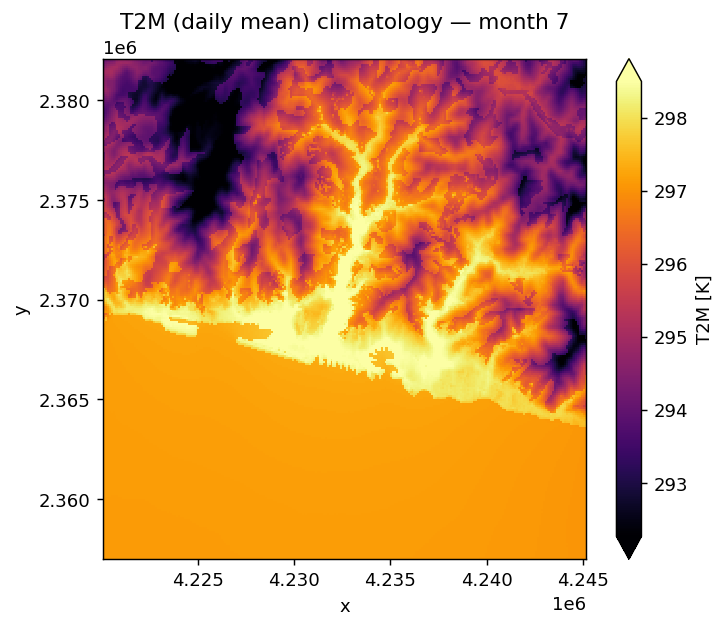

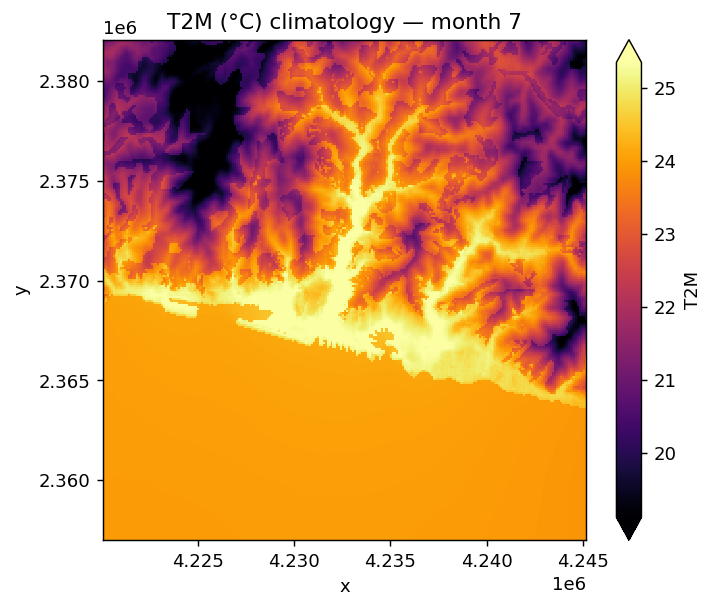

In [17]:
# July map from T2M climatology
month_to_show = 7  # July

# in Kelvin
ax = clim_monthly.sel(month=month_to_show).plot.imshow(
    x="x", y="y", robust=True, cmap="inferno", figsize=(6,5)
)
ax.axes.set_title(f"T2M (daily mean) climatology — month {month_to_show}")
plt.show()

# show in °C 
t2m_c = clim_monthly - 273.15
ax = t2m_c.sel(month=month_to_show).plot.imshow(
    x="x", y="y", robust=True, cmap="inferno", figsize=(6,5)
)
ax.axes.set_title(f"T2M (°C) climatology — month {month_to_show}")
plt.show()

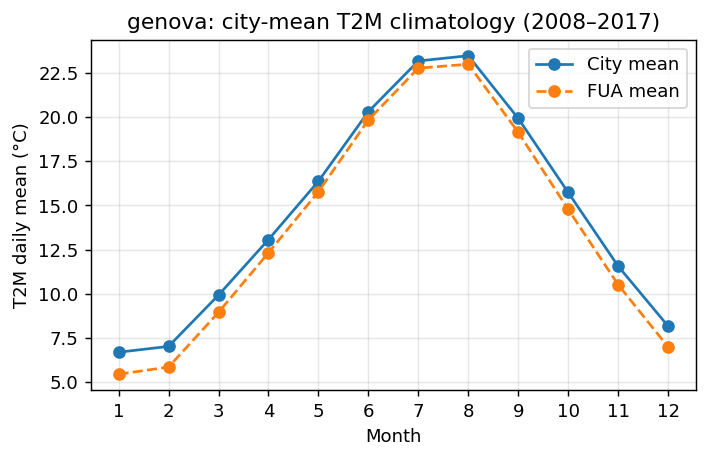

,month,T2M_mean_C_city,T2M_mean_C_FUA
0,1,6.707178,5.464698
1,2,7.037188,5.868678
2,3,9.935872,8.960937
3,4,13.071620,12.328755
4,5,16.370468,15.779244
5,6,20.300713,19.833784
6,7,23.166363,22.761844
7,8,23.462652,22.982025
8,9,19.919460,19.131515
9,10,15.733979,14.778503


In [18]:
# climatology
city_monthly_mean_C = city_monthly_mean - 273.15
city_monthly_mean_FUA_C = city_monthly_mean_FUA - 273.15  

fig, ax = plt.subplots(figsize=(6,3.5))
ax.plot(range(1,13), city_monthly_mean_C.values, marker="o", label="City mean")
ax.plot(range(1,13), city_monthly_mean_FUA_C.values, marker="o", linestyle="--", label="FUA mean")  
ax.set_xticks(range(1,13)); ax.set_xlabel("Month")
ax.set_ylabel("T2M daily mean (°C)")
ax.set_title(f"{CITY}: city-mean T2M climatology (2008–2017)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

display(pd.DataFrame({
    "month": range(1,13),
    "T2M_mean_C_city": city_monthly_mean_C.values,
    "T2M_mean_C_FUA":  city_monthly_mean_FUA_C.values
}))

**Cooling Efficiency of street trees csv**: Each coefficient tells you: by how much increasing the level of green space (measured by GVI) will change the heat metric (here attached, for the monthly average of minimum, mean, and maximum of 1) air temperature and 2) wet-bulb globe temperature (WBGT) in that city and in that LCZ) in each month of the year. Specifically, the variable "coef" will give you how many Celsius degrees will a 1 unit increase in GVI drive.

Each of the CSV gives a city (UC_NM_MN), a month, a lcz class, a coeff, coef_abs 

In [19]:
print("CoolingEff folder:", p_CoolEff) # printing the path to the folder, what is inside ? 6 csv

coolingeff_csvs = sorted(p_CoolEff.glob("*.csv"))
if not coolingeff_csvs:
    print("No CSV files found in CoolingEff.")
else:
    print(f"Found {len(coolingeff_csvs)} CSV file(s):")
    for i, f in enumerate(coolingeff_csvs, 1):
        print(f"  {i:2d}. {f.name}")

    # reading and displaying heads: looking at the first rows of each of these 6 csv 
    coolingeff = {}
    for f in coolingeff_csvs:
        print("\n" + "="*90)
        print(f"FILE: {f.name}")
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print("Could not read CSV:", e)
            continue
        coolingeff[f.stem] = df
        print(f"  shape: {df.shape}")
        print(f"  columns: {list(df.columns)}")
        display(df.head(5)) # showing the head of each of these 6 csv 

CoolingEff folder: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff
Found 6 CSV file(s):
   1. outer_2_max.csv
   2. outer_2_mean.csv
   3. outer_2_min.csv
   4. outer_2_wbgt_max.csv
   5. outer_2_wbgt_mean.csv
   6. outer_2_wbgt_min.csv

FILE: outer_2_max.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_max,1,Compact lowrise,0.074672,0.023864
1,2,Accra_max,2,Compact lowrise,0.074637,0.023864
2,3,Accra_max,3,Compact lowrise,0.074191,0.023864
3,4,Accra_max,4,Compact lowrise,0.075146,0.023864
4,5,Accra_max,5,Compact lowrise,0.078642,0.023864



FILE: outer_2_mean.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra,1,Compact lowrise,0.015239,0.004262
1,2,Accra,2,Compact lowrise,0.015121,0.004262
2,3,Accra,3,Compact lowrise,0.014896,0.004262
3,4,Accra,4,Compact lowrise,0.014972,0.004262
4,5,Accra,5,Compact lowrise,0.015449,0.004262



FILE: outer_2_min.csv
  shape: (11064, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


...

,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_max_wbgt,1,Compact lowrise,-0.026608,-0.007932
1,2,Accra_max_wbgt,2,Compact lowrise,-0.026713,-0.007932
2,3,Accra_max_wbgt,3,Compact lowrise,-0.026638,-0.007932
3,4,Accra_max_wbgt,4,Compact lowrise,-0.026394,-0.007932
4,5,Accra_max_wbgt,5,Compact lowrise,-0.026809,-0.007932



FILE: outer_2_wbgt_mean.csv
  shape: (10872, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_wbgt,1,Compact lowrise,-0.012626,-0.003293
1,2,Accra_wbgt,2,Compact lowrise,-0.012363,-0.003293
2,3,Accra_wbgt,3,Compact lowrise,-0.012189,-0.003293
3,4,Accra_wbgt,4,Compact lowrise,-0.012197,-0.003293
4,5,Accra_wbgt,5,Compact lowrise,-0.012444,-0.003293



FILE: outer_2_wbgt_min.csv
  shape: (11064, 6)
  columns: ['Unnamed: 0', 'UC_NM_MN', 'month', 'lcz', 'coef', 'coef_abs']


,Unnamed: 0,UC_NM_MN,month,lcz,coef,coef_abs
0,1,Accra_min_wbgt,1,Compact lowrise,-0.018787,-0.00449
1,2,Accra_min_wbgt,2,Compact lowrise,-0.018208,-0.00449
2,3,Accra_min_wbgt,3,Compact lowrise,-0.017870,-0.00449
3,4,Accra_min_wbgt,4,Compact lowrise,-0.017920,-0.00449
4,5,Accra_min_wbgt,5,Compact lowrise,-0.018287,-0.00449


In [20]:
lcz_out = OUTP("lcz_masked_fua.tif")
with rasterio.open(lcz_out, "w", **lcz_meta) as dst:
    dst.write(lcz_fua, 1)
print("Saved:", lcz_out)

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/lcz_masked_fua.tif
